In [98]:
import numpy as np
from pyscf import gto, scf, ci
import pyscf
import pandas as pd
from MSTOkG.MSTOOptpar import *

import matplotlib.pyplot as mpl

import pylab as pl

# Set the global default font size
mpl.rcParams.update({'font.size': 15}) 

In [1]:
## Adapted from VSP's code:

# #Geometry and other info: 
# mol = gto.M(
#     atom='H 0.0 0.0 0.; H 0.0 0.0 0.7408481486',
#     basis='sto3g') #If at all you want uncontracted for whatever inexplicable reasons, use unc-sto-3g instead! 

def PDM(mol):
    # r = [1]
    # args = [mol, atom]
    # rmin = minimize(E, r, args=args)
    # Emin = rmin.fun
    # d = rmin.x[0]
    
    # mol.atom = atom.replace('bl', f"{d}")
    # mol.build()
    
    #HF and CISD: 
    mf = scf.RHF(mol).run()
    myci = ci.CISD(mf).run()
    
    #To get pdm, you need to multiply rdm1 and pdm int, both in mo basis. This is the tricky part in any property calculation. 
    #Note that rdm1 can directly be obtained in mo basis. But we need to convert pdm ints to mo basis. 
    #In dip_elec: notice that I put in minus sign by hand. 
    #In the same line, x runs over x,y,z. i,j over all spin MOs. So dip_elec is actually a list with 3 entries for 3 comps. 
    #The rest of what folows is obvious! 
    dm1_mo = myci.make_rdm1()
    C = mf.mo_coeff 
    dip_ao = mol.intor('int1e_r', hermi=1) 
    dip_mo = np.array([C.T @ dip_ao[x] @ C for x in range(3)]) 
    dip_elec = -np.einsum('xij,ji->x', dip_mo, dm1_mo)
    dip_nuc = np.einsum('i,ix->x', mol.atom_charges(), mol.atom_coords())
    dip_tot = dip_elec + dip_nuc
    
    to_debye = 2.541746
    # print("Electronic pdm (D):", dip_elec*to_debye)
    # print("Nuclear pdm (D):", dip_nuc*to_debye)
    # print("Total pdm (a.u.):", dip_tot*to_debye)
    return {'PDM_elec': dip_elec*to_debye, 'PDM_nuc': dip_nuc*to_debye, 'PDM_tot': dip_tot*to_debye}

In [33]:
from scipy.optimize import minimize

def E(r, mol, atom=None):
    if atom is not None:
        mol.atom = atom.replace('bl', f"{r[0]}")
        mol.build()
    en = getEnergies(mol, nroots=4, fci=True, cisd=False)
    return en['FCI'][0]

def getEqBondLength(mol, atom, r_range):
    rlst = np.linspace(*r_range, 20)
    Elst = []
    for r in rlst:
        Elst.append(E([r], mol, atom))

    from scipy.interpolate import interp1d
    f = interp1d(rlst, Elst, kind='cubic')
    # pl.plot(rlst, Elst)
    # rnew = np.linspace(rlst[0], rlst[-1], 100)
    # pl.plot(rnew, f(rnew))
    rmin = minimize(f, rlst[np.argwhere(Elst==np.min(Elst))][0])
    # pl.axvline(x=rmin.x)
    return rmin.x, f



In [13]:
# Check whether it works

basis = 'sto-2g'

d = 1.5
mol = pyscf.M(
                            atom = f"Li 0.0 0.0 0.0; H 0.0 0.0 {d};", # in Angstrom
                            basis = basis,
                            symmetry = False,
                            spin=0
                        )
atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
args = [mol, atom]
r_range = [1,2]

rmin, E_vs_r = getEqBondLength(mol, atom, r_range)


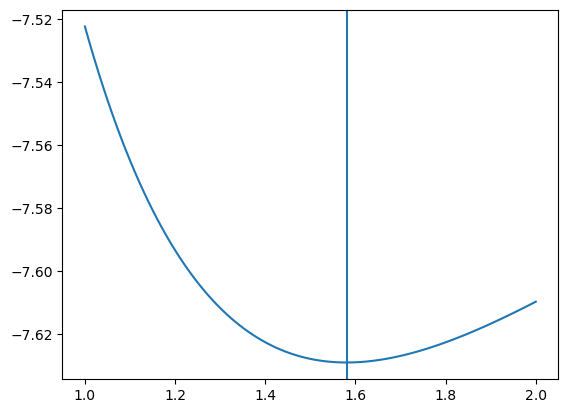

In [14]:
# plot the E vs r curve
rnew = np.linspace(*r_range, 100)
pl.plot(rnew, E_vs_r(rnew))
pl.axvline(x=rmin)

In [15]:
# compute the pdm at the equilibrium bond length

mol.atom = atom.replace('bl', f"{rmin[0]}")
mol.build()
PDM(mol)['PDM_tot'], np.linalg.norm(PDM(mol)['PDM_tot'])

converged SCF energy = -7.6100532767955
E(RCISD) = -7.629094487435538  E_corr = -0.01904121064004025
converged SCF energy = -7.6100532767955
E(RCISD) = -7.629094487435538  E_corr = -0.01904121064004031


(array([ 2.07317529e-15, -2.61095612e-16, -4.69529579e+00]),
 np.float64(4.695295793255976))

In [121]:
# Compute the PDMs at equilibrium bondlength (set compute=True).
# Otherwise it will attempt to read existing data

compute=False
if compute:
    df = pd.DataFrame(columns="Basis PDM(D) r_min(A) Emin(Ha)".split(' '))
    d = 1
    r_range = [1.3, 1.9]
    atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
    for basis in [f'sto-{k}g' for k in range(2,7)] + ['6-31g']:
        print(f"Basis: {basis} ", end=' ', flush=True)
        mol = pyscf.M(
                            atom = f"Li 0.0 0.0 0.0; H 0.0 0.0 {d};", # in Angstrom
                            basis = basis,
                            symmetry = False,
                            spin=0
                        )
        
        rmin, E_vs_r = getEqBondLength(mol, atom, r_range)
        rmin = rmin[0]
        mol.atom = atom.replace('bl', f"{rmin}")
        mol.build()

        pdm = np.linalg.norm(PDM(mol)['PDM_tot'])
        
        print(f"basis: {basis}, PDM = {pdm} D; r = {rmin} Ang; Emin = {np.float64(E_vs_r(rmin))} Ha;")
        df.loc[len(df)] = [basis, pdm, rmin, np.float64(E_vs_r(rmin))]
        print("[Complete]", flush=True)
    
    dirname = 'testdata'
    prefix = 'MOBS'
    for k in range(2,12):
        basisset = {}
        basis = f"msto-{k:02d}g"
        print(f"Basis: {basis} ", flush=True)
        # update atomic basis sets to msto-kg
        for element in [mol.atom_symbol(i) for i in range(len(mol.atom_charges()))]:
            basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
            
        mol = pyscf.M(
                            atom = f"Li 0.0 0.0 0.0; H 0.0 0.0 {d};", # in Angstrom
                            basis = basisset,
                            symmetry = False,
                            spin=0
                        )
        # atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
        rmin, E_vs_r = getEqBondLength(mol, atom, r_range)
        rmin = rmin[0]
        mol.atom = atom.replace('bl', f"{rmin}")
        mol.build()

        pdm = np.linalg.norm(PDM(mol)['PDM_tot'])
        
        print(f"basis: {basis}, PDM = {pdm} D; r = {rmin} Ang; Emin = {np.float64(E_vs_r(rmin))} Ha;")
        df.loc[len(df)] = [basis, pdm, rmin, np.float64(E_vs_r(rmin))]
        print("[Complete]", flush=True)
    df.to_excel('PDM.xlsx', index=False)
else:
    df = pd.read_excel('PDM.xlsx')

In [124]:
print(df.to_latex(index=False))

\begin{tabular}{lrrr}
\toprule
Basis & PDM(D) & r_min(A) & Emin(Ha) \\
\midrule
sto-2g & 4.695295 & 1.580252 & -7.629106 \\
sto-3g & 4.627168 & 1.547492 & -7.882762 \\
sto-4g & 4.677547 & 1.542924 & -7.948353 \\
sto-5g & 4.689590 & 1.542267 & -7.966887 \\
sto-6g & 4.691183 & 1.542241 & -7.972782 \\
6-31g & 5.606067 & 1.671679 & -7.998903 \\
msto-02g & 3.577366 & 1.730383 & -7.740918 \\
msto-03g & 3.634864 & 1.711600 & -7.946667 \\
msto-04g & 3.676004 & 1.701536 & -7.989670 \\
msto-05g & 3.673202 & 1.700454 & -7.999509 \\
msto-06g & 3.667366 & 1.699979 & -8.001859 \\
msto-07g & 3.665542 & 1.700525 & -8.001866 \\
msto-08g & 3.673407 & 1.700478 & -8.002054 \\
msto-09g & 3.676092 & 1.699969 & -8.002229 \\
msto-10g & 3.671394 & 1.700143 & -8.002666 \\
msto-11g & 3.697085 & 1.696562 & -8.001780 \\
\bottomrule
\end{tabular}



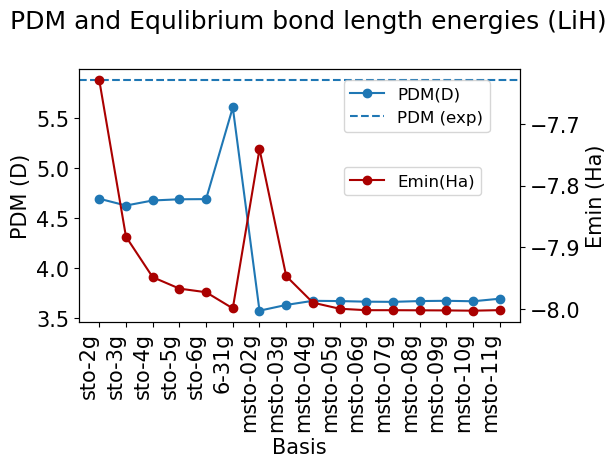

In [103]:
fig = pl.figure()
ax = fig.add_subplot(1,1,1)
ax2 = ax.twinx()
df.plot(x='Basis', y=['PDM(D)'], ax=ax, rot=90, marker='o')
ax.axhline(y=5.88, linestyle='dashed', label="PDM (exp)")
df.plot(x='Basis', y=['Emin(Ha)'], ax=ax2, color="#aa0000", marker='o')
# ax2.axhline(y=-8.07, linestyle='dashed', color="#aa0000", label=r"E$_GS$ (exp)")

ax.set_ylabel('PDM (D)')
ax2.set_ylabel('Emin (Ha)')
ax2.legend(loc=(0.6,0.5), fontsize=12)
ax.legend(loc=(0.6,0.75), fontsize=12)

ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df['Basis'], rotation=90, ha='right')

fig.suptitle("PDM and Equlibrium bond length energies (LiH)")
fig.tight_layout()
fig.savefig("PDM_Emin_vs_Basis.png", dpi=300)

In [104]:
# Compute the PDMs at equilibrium bondlength (exp value) (set compute=True).
# Otherwise it will attempt to read existing data

compute=False
if compute:
    
    df = pd.DataFrame(columns="Basis PDM(D) r(A) E(Ha)".split(' '))
    d = 1.5949
    # r_range = [1.3, 1.9]
    atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
    for basis in [f'sto-{k}g' for k in range(2,7)] + ['6-31g']:
        print(f"Basis: {basis} ", end=' ', flush=True)
        mol = pyscf.M(
                            atom = f"Li 0.0 0.0 0.0; H 0.0 0.0 {d};", # in Angstrom
                            basis = basis,
                            symmetry = False,
                            spin=0
                        )
        
        # rmin, E_vs_r = getEqBondLength(mol, atom, r_range)
        # rmin = rmin[0]
        
        # mol.atom = atom.replace('bl', f"{rmin}")
        mol.build()

        pdm = np.linalg.norm(PDM(mol)['PDM_tot'])
        en = np.float64(E(d, mol))
        print(f"basis: {basis}, PDM = {pdm} D; r = {d} Ang; Emin = {en} Ha;")
        df.loc[len(df)] = [basis, pdm, d, np.float64(en)]
        print("[Complete]", flush=True)
    
    dirname = 'testdata'
    prefix = 'MOBS'
    for k in range(2,12):
        basisset = {}
        basis = f"msto-{k:02d}g"
        print(f"Basis: {basis} ", flush=True)
        # update atomic basis sets to msto-kg
        for element in [mol.atom_symbol(i) for i in range(len(mol.atom_charges()))]:
            basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
            
        mol = pyscf.M(
                            atom = f"Li 0.0 0.0 0.0; H 0.0 0.0 {d};", # in Angstrom
                            basis = basisset,
                            symmetry = False,
                            spin=0
                        )
        # atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
        # rmin, E_vs_r = getEqBondLength(mol, atom, r_range)
        # rmin = rmin[0]
        # mol.atom = atom.replace('bl', f"{rmin}")
        mol.build()

        pdm = np.linalg.norm(PDM(mol)['PDM_tot'])
        en = np.float64(E(d, mol))
        print(f"basis: {basis}, PDM = {pdm} D; r = {d} Ang; Emin = {en} Ha;")
        df.loc[len(df)] = [basis, pdm, d, np.float64(en)]
        print("[Complete]", flush=True)
    df.to_excel('PDM_fixedr.xlsx', index=False)
else:
    df = pd.read_excel('PDM_fixedr.xlsx')

In [105]:
df

,Basis,PDM(D),r(A),E(Ha)
0,sto-2g,4.695748,1.5949,-7.629071
1,sto-3g,4.620427,1.5949,-7.882403
2,sto-4g,4.675286,1.5949,-7.947920
3,sto-5g,4.687546,1.5949,-7.966443
4,sto-6g,4.689248,1.5949,-7.972337
5,6-31g,5.503552,1.5949,-7.998274
6,msto-02g,3.703454,1.5949,-7.739097
7,msto-03g,3.733499,1.5949,-7.945401
8,msto-04g,3.764721,1.5949,-7.988617
9,msto-05g,3.761772,1.5949,-7.998482


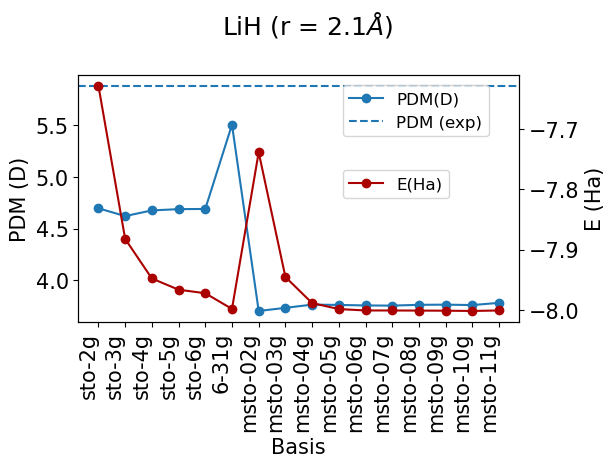

In [107]:
fig = pl.figure()
ax = fig.add_subplot(1,1,1)
ax2 = ax.twinx()
df.plot(x='Basis', y=['PDM(D)'], ax=ax, rot=90, marker='o')
ax.axhline(y=5.88, linestyle='dashed', label="PDM (exp)")
df.plot(x='Basis', y=['E(Ha)'], ax=ax2, color="#aa0000", marker='o')
# ax2.axhline(y=-8.07, linestyle='dashed', color="#aa0000", label=r"E$_GS$ (exp)")

ax.set_ylabel('PDM (D)')
ax2.set_ylabel('E (Ha)')
ax2.legend(loc=(0.6,0.5), fontsize=12)
ax.legend(loc=(0.6,0.75), fontsize=12)

ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df['Basis'], rotation=90, ha='right')
fig.suptitle(f"LiH (r = {d}"+r"$\AA$)")
fig.tight_layout()


In [108]:
# E vs r




df = pd.DataFrame(columns="r(A)".split(' '))
# d = 1.5949
rlst = np.linspace(1.1, 2.1, 10)
df['r(A)']=rlst
mol = pyscf.M(
                        atom = f"Li 0.0 0.0 0.0; H 0.0 0.0 1;", # in Angstrom
                        basis = 'sto-2g',
                        symmetry = False,
                        spin=0
                    )
atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
for basis in [f'sto-{k}g' for k in range(2,7)] + ['6-31g']:
    print(f"Basis: {basis} ", flush=True)
    enlst = []
    for d in rlst:
        mol.basis = basis
        mol.atom = atom.replace(' bl', f' {d}')
        mol.build()
        en = getEnergies(mol, nroots=4, fci=True, cisd=False)['FCI'][0]
        enlst.append(en)
    df.insert(loc = len(df.columns), column=f'E[{basis}]', value=enlst)


dirname = 'testdata'
prefix = 'MOBS'
for k in range(2,12):
    basisset = {}
    basis = f"msto-{k:02d}g"
    print(f"Basis: {basis} ", flush=True)
    # update atomic basis sets to msto-kg
    for element in [mol.atom_symbol(i) for i in range(len(mol.atom_charges()))]:
        basisset.update(loadBSI(os.path.join(dirname, f"{prefix}_{element}_{basis}.pickle"))['mol_CISD'].mol.basis)
        
    mol.basis = basisset
    enlst = []
    for d in rlst:
        mol.atom = atom.replace(' bl', f' {d}')
        mol.build()
        en = getEnergies(mol, nroots=4, fci=True, cisd=False)['FCI'][0]
        enlst.append(en)
    df.insert(loc = len(df.columns), column=f'E[{basis}]', value=enlst)
    # atom = "Li 0.0 0.0 0.0; H 0.0 0.0 bl;"
    # rmin, E_vs_r = getEqBondLength(mol, atom, r_range)
    # rmin = rmin[0]
    # mol.atom = atom.replace('bl', f"{rmin}")
    # mol.build()

#     pdm = np.linalg.norm(PDM(mol)['PDM_tot'])
#     en = np.float64(E(d, mol))
#     print(f"basis: {basis}, PDM = {pdm} D; r = {d} Ang; Emin = {en} Ha;")
#     df.loc[len(df)] = [basis, pdm, d, np.float64(en)]
#     print("[Complete]", flush=True)
# # df.to_excel('PDM_fixedr.xlsx', index=False)
df.to_excel("LiH_E_vs_r.xlsx", index=False)

Basis: sto-2g 
Basis: sto-3g 
Basis: sto-4g 
Basis: sto-5g 
Basis: sto-6g 
Basis: 6-31g 
Basis: msto-02g 
Basis: msto-03g 
Basis: msto-04g 
Basis: msto-05g 
Basis: msto-06g 
Basis: msto-07g 
Basis: msto-08g 
Basis: msto-09g 
Basis: msto-10g 
Basis: msto-11g 


In [109]:
df

,r(A),E[sto-2g],E[sto-3g],E[sto-4g],E[sto-5g],E[sto-6g],E[6-31g],E[msto-02g],E[msto-03g],E[msto-04g],E[msto-05g],E[msto-06g],E[msto-07g],E[msto-08g],E[msto-09g],E[msto-10g],E[msto-11g]
0,1.100000,-7.564932,-7.825537,-7.891832,-7.910533,-7.916516,-7.932207,-7.660814,-7.874420,-7.919069,-7.929334,-7.931601,-7.931586,-7.931762,-7.931959,-7.932437,-7.931718
1,1.211111,-7.595936,-7.854731,-7.920904,-7.939529,-7.945470,-7.962074,-7.695170,-7.906460,-7.950686,-7.960865,-7.963184,-7.963169,-7.963356,-7.963555,-7.964012,-7.963304
2,1.322222,-7.614796,-7.871768,-7.937756,-7.956341,-7.962252,-7.980678,-7.716940,-7.926190,-7.970079,-7.980134,-7.982486,-7.982470,-7.982662,-7.982859,-7.983301,-7.982585
3,1.433333,-7.624982,-7.880276,-7.946056,-7.964615,-7.970513,-7.991551,-7.730062,-7.937757,-7.981356,-7.991307,-7.993672,-7.993657,-7.993849,-7.994042,-7.994477,-7.993729
4,1.544444,-7.628887,-7.882761,-7.948353,-7.966886,-7.972781,-7.997072,-7.737256,-7.943896,-7.987226,-7.997110,-7.999472,-7.999465,-7.999655,-7.999842,-8.000275,-7.999476
5,1.655556,-7.628240,-7.881012,-7.946446,-7.964958,-7.970851,-7.998877,-7.740404,-7.946396,-7.989489,-7.999337,-8.001690,-8.001693,-8.001882,-8.002061,-8.002496,-8.001635
6,1.766667,-7.624346,-7.876342,-7.941638,-7.960138,-7.966026,-7.998110,-7.740813,-7.946438,-7.989354,-7.999183,-8.001529,-8.001541,-8.001729,-8.001898,-8.002337,-8.001411
7,1.877778,-7.618210,-7.869728,-7.934889,-7.953393,-7.959273,-7.995585,-7.739387,-7.944828,-7.987643,-7.997463,-7.999804,-7.999824,-8.000010,-8.000169,-8.000612,-7.999624
8,1.988889,-7.610616,-7.861912,-7.926932,-7.945450,-7.951323,-7.991886,-7.736757,-7.942139,-7.984923,-7.994740,-7.997080,-7.997105,-7.997289,-7.997438,-7.997884,-7.996839
9,2.100000,-7.602171,-7.853463,-7.918336,-7.936869,-7.942741,-7.987440,-7.733372,-7.938783,-7.981592,-7.991413,-7.993754,-7.993782,-7.993964,-7.994103,-7.994554,-7.993456


Text(0.5, 1.0, 'LiH')

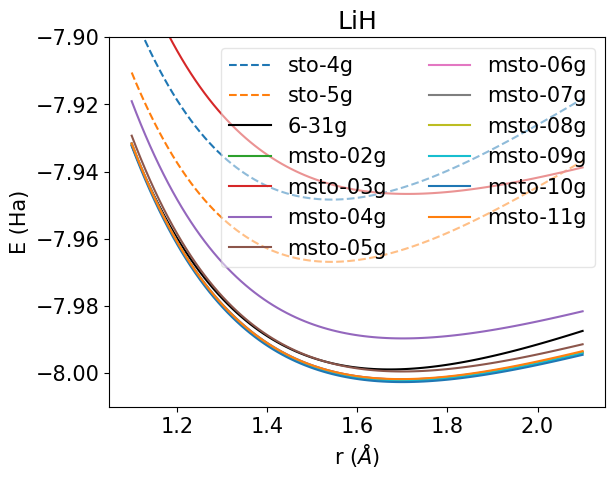

In [111]:
from scipy.interpolate import interp1d
arr = df.values
x = arr[:,0]
x1 = np.linspace(x[0], x[-1], 100)
pl.figure()

for i in range(3, 5):
    label = df.columns[i][2:-1]
    y = arr[:,i]
    f = interp1d(x,y, kind='cubic')
    pl.plot(x1,f(x1), label=label, linestyle='--')

i = 6
label = df.columns[i][2:-1]
y = arr[:,i]
f = interp1d(x,y, kind='cubic')
pl.plot(x1,f(x1), label=label, linestyle='-', color='#000000')


for i in range(7, len(df.columns)):
    label = df.columns[i][2:-1]
    y = arr[:,i]
    f = interp1d(x,y, kind='cubic')
    pl.plot(x1,f(x1), label=label, linestyle='-')

pl.legend(ncols=2, framealpha=0.5)
pl.ylim([-8.01, -7.9])
pl.ylabel("E (Ha)")
pl.xlabel(r"r ($\AA$)")
pl.title("LiH")

Text(0.5, 1.0, 'LiH')

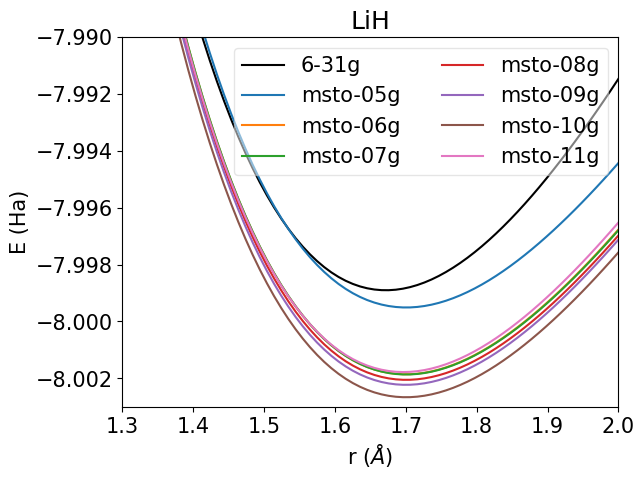

In [120]:
from scipy.interpolate import interp1d
arr = df.values
x = arr[:,0]
x1 = np.linspace(x[0], x[-1], 100)
pl.figure()

# for i in range(3, 5):
#     label = df.columns[i][2:-1]
#     y = arr[:,i]
#     f = interp1d(x,y, kind='cubic')
#     pl.plot(x1,f(x1), label=label, linestyle='--')

i = 6
label = df.columns[i][2:-1]
y = arr[:,i]
f = interp1d(x,y, kind='cubic')
pl.plot(x1,f(x1), label=label, linestyle='-', color='#000000')


for i in range(10, len(df.columns)):
    label = df.columns[i][2:-1]
    y = arr[:,i]
    f = interp1d(x,y, kind='cubic')
    pl.plot(x1,f(x1), label=label, linestyle='-')

pl.legend(ncols=2, framealpha=0.5)
pl.ylim([-8.003, -7.99])
pl.xlim([1.3, 2.0])
pl.ylabel("E (Ha)")
pl.xlabel(r"r ($\AA$)")
pl.title("LiH")
